# Draft

In [42]:
import glob

import ot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import MDS, TSNE
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import KMeans

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, LeaveOneOut, GridSearchCV, cross_val_predict, permutation_test_score
from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFECV
from sklearn.decomposition import PCA

from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression

from src.repartition.data_loading import get_annotation, tif_to_real_mask
from src.repartition.data_analysis import *
from src.repartition.visualization import *
from src.repartition.constants import PROJECT_ROOT, PATH_PATIENT_DATA, MULTI_SLIDES_PATIENTS
from src.repartition.TissueCollection import * 
from src.repartition.geometry_funcs import *

In [43]:
%load_ext autoreload
%autoreload 1
%aimport src.repartition.data_loading, src.repartition.data_analysis, src.repartition.visualization, src.repartition.constants, src.repartition.TissueCollection, src.repartition.geometry_funcs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load paths

In [ ]:
project_root = PROJECT_ROOT

In [ ]:
annot_dir = project_root / 'data/repartition/annotation/'
annotations_paths = glob.glob(str(annot_dir) + "/" +'*.tif')
annotations_paths = np.array(annotations_paths)
slides_annot = get_annotation(annotations_paths, tif_to_real_mask)

In [ ]:
export_mask_pdf(
    slides_annot,
    output="masks.pdf",
    saveimg=False
)

In [ ]:
distance_data, distribution_data = get_tissues_data(
    slides_annot, find_center_barycentre, 
    return_kde=True, return_hist=False, 
    local_ratio=True,
)

In [ ]:
export_furthest_tissue_pdf(
    slides_annot,
    find_center_barycentre, 
    distance_data, 
    tissue_type='tumor',
    output="furthest_tumors.pdf",
    saveimg=True
)

## Dispersion Score

In [ ]:
tbo_infos = dict()
scores = []
for sld_name in slides_annot:
    masks = slides_annot[sld_name]

    if not np.any(masks['tumor']):
        continue

    tumor_mask = masks['tumor']
    bed_mask = masks['tumor_bed']

    s = compute_tumor_spread(tumor_mask, bed_mask)
    tbo_infos.update({
        sld_name : s
    })
    scores.append(s)
scores = np.array(scores)

### Evaluation

In [ ]:
# Il faut retirer les slides puzzles avant d'exécuter cette cellules
dispersion_gt = pd.read_csv(project_root / 'data/repartition/dispersion_ground_truth.csv')
tbo = np.array([score for name, score in tbo_infos.items() if not name.endswith("0")])

is_circumscribed = dispersion_gt['dispersion'] == 'Concentrique'
is_scattered = dispersion_gt['dispersion'] == 'Diffus'

print(f"circumscribed - min tbo = {tbo[is_circumscribed].min():.3f} - max tbo = {tbo[is_circumscribed].max():.3f}")
print(f"scattered     - min tbo = {tbo[is_scattered].min():.3f} - max tbo = {tbo[is_scattered].max():.3f}")

fig, (ax1, ax2) = plt.subplots(2, sharex=True)
ax1.hist(tbo[is_circumscribed])
ax1.set_ylabel("Nombre de lames")
ax1.set_title("Répartition Circonscrite")
ax1.grid(True, linewidth=0.4)

ax2.hist(tbo[is_scattered])
ax2.set_xlabel("Valeurs du scores")
ax2.set_ylabel("Nombre de lames")
ax2.set_title("Répartition dispersée")
ax2.grid(True, linewidth=0.4)

plt.tight_layout()

## Export all data

In [ ]:
tum_data = get_furthest_tumors(distance_data, by='id-slide')
tum_border = {
    id_sld: ratio_border_tumor(masks)
    for id_sld, masks in slides_annot.items() if np.any(masks['tumor'])
}
tum_data['score-dispersion'] = tum_data['id-slide'].map(tbo_infos)
tum_data['tumor-border'] = tum_data['id-slide'].map(tum_border)

duplicate = tum_data.duplicated(subset=['id-patient'], keep='first')
tum_data.drop_duplicates(subset=['id-patient'], keep='first', inplace=True) # Pour ne garder que les lames reconstituées et les lames uniques.
tum_data.reset_index(inplace=True)
tum_data.drop(columns=['index'], inplace=True)

tum_data.to_csv('tumors_data_testo.csv')

In [ ]:
slides_tumor = np.array(get_tumor_slides(slides_annot))
names = np.array([sld_name for sld_name, _ in slides_tumor])
order = np.argsort(names)

In [ ]:
plot_slide_grid(
    slides_tumor[order][~duplicate], 
    imgtitles=[f"{name}\n score : {s:.2f}" for s, name in zip(scores[order][~duplicate], names[order][~duplicate])], 
    output="Score de dispersion par lames",
    figsize=(16, 16)
)

In [ ]:
is_circumscribed = scores[order][~duplicate] < 0.72
plot_slide_grid(slides_tumor[order][~duplicate][is_circumscribed], imgtitles=[f"{s:.2f}" for s in scores[order][~duplicate][is_circumscribed]], output="Score de dispersion pour cas circonscrits")

is_scattered = scores[order][~duplicate] > 0.76
plot_slide_grid(slides_tumor[order][~duplicate][is_scattered], imgtitles=[f"{s:.2f}" for s in scores[order][~duplicate][is_scattered]], output="Score de dispersion pour cas dispersés")

In [ ]:
export_tumor_dispersion_pdf(
    slides_tumor[order][~duplicate],
    scores[order][~duplicate],
    output="score_dispersion.pdf",
    saveimg=True,
)

## Clustering

In [75]:
n_clusters = 4

feat = extract_features(slides_annot, distance_data)

distrib_type = 'kde'

distrib = get_distrib_model(
    model=distrib_type,
    distribution_data=distribution_data, 
    slide_annotations=slides_annot,
)

dist_matrix = compute_distance_matrix(
    feat
)


dist_matrix = dist_matrix
clustering = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='precomputed',
    linkage='complete',           # 'ward' incompatible avec precomputed
)
labels_agglo = clustering.fit_predict(dist_matrix)

mds = MDS(n_components=2, metric='precomputed', random_state=42, n_init=1, init='classical_mds')
X_mds = mds.fit_transform(dist_matrix)

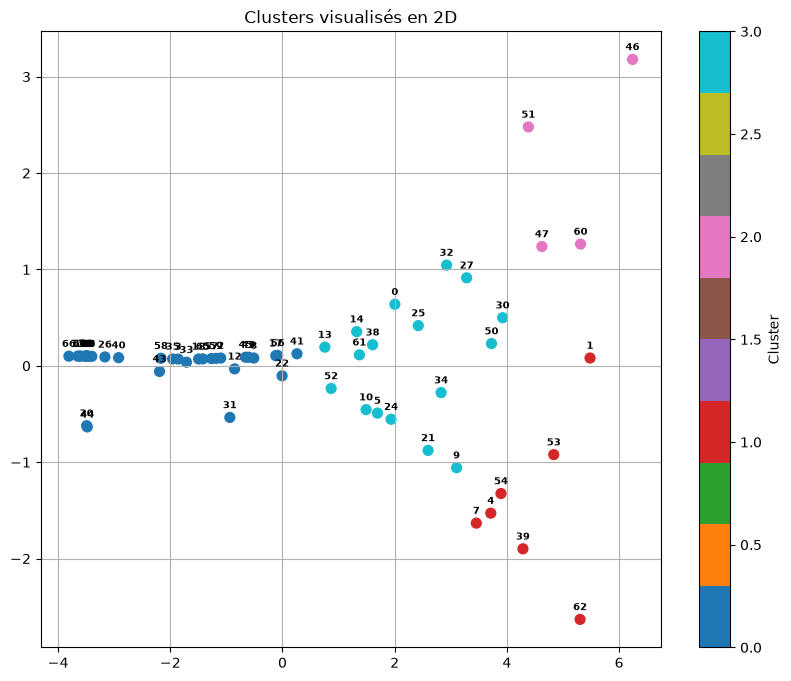

In [76]:
X = X_mds
labels = labels_agglo

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=50)
plt.colorbar(scatter, label='Cluster')

for i, (x, y) in enumerate(X[:, :2]):
    ax.annotate(str(i), (x, y), fontsize=7, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

plt.title('Clusters visualisés en 2D')
plt.grid()
plt.show()

## Interactive visualization

In [47]:
from bokeh.plotting import figure, output_notebook, show, reset_output
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.embed import file_html
from bokeh.resources import CDN
import base64
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.transform import factor_cmap
from bokeh.palettes import Set1_9, Category20, Turbo256, Category10
from bokeh.models import Legend, LegendItem

In [72]:
def composite_to_base64_transparent(composite_img, tolerance=90):
    img_uint8 = (composite_img * 255).astype(np.uint8)
    img_bgra = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGRA)
    
    lower_white = 255 - tolerance
    bg_mask = (img_bgra[:, :, 0] >= lower_white) & \
              (img_bgra[:, :, 1] >= lower_white) & \
              (img_bgra[:, :, 2] >= lower_white)
    
    img_bgra[bg_mask, 3] = 0  
    
    img_bgra = cv2.resize(img_bgra, (200, 200), interpolation=cv2.INTER_AREA)

    _, buffer = cv2.imencode('.png', img_bgra)
    b64_string = base64.b64encode(buffer).decode('utf-8')
    
    return f"data:image/png;base64,{b64_string}"

b64_images = []
slides_tumor = np.array(get_tumor_slides(slides_annot))
for sld in slides_tumor:
    masks_dict = sld[1]
    composite = make_composite(masks_dict)
    b64 = composite_to_base64_transparent(composite, tolerance=30)
    b64_images.append(b64)

df = pd.DataFrame({
    'x': X[:, 0],
    'y': X[:, 1],
    'cluster': labels,
    'cluster_str': labels.astype(str),
    'img_data': b64_images
})

# --- Visualisation  ---

reset_output()
output_notebook()
datasource = ColumnDataSource(df)

unique_clusters = sorted(df['cluster_str'].unique())

if len(unique_clusters) <= 9:
    palette = Set1_9[:max(3, len(unique_clusters))] 
elif len(unique_clusters) <= 20:
    palette = Category20[len(unique_clusters)]
else:
    step = len(Turbo256) // len(unique_clusters)
    palette = [Turbo256[i * step] for i in range(len(unique_clusters))]

color_mapper = factor_cmap('cluster_str', palette=palette, factors=unique_clusters)

palette = Category10[len(unique_clusters)]
color_mapper = factor_cmap('cluster_str', palette=palette, factors=unique_clusters)

plot = figure(
    title="Visualisation des Clusters d'Images",
    tools="pan,wheel_zoom,reset,box_zoom,save",
    width=1050,
    height=700,
    background_fill_color="#fafafa"
)

scatter = plot.scatter(
    'x', 'y', 
    source=datasource, 
    size=12, 
    alpha=1, # Augmenté de 0.7 à 0.85 pour rendre la couleur plus dense
    fill_color=color_mapper,
    line_color="black", # Ajouter une fine ligne blanche fait "poper" les couleurs
    line_width=0.8,
    legend_field='cluster_str',
)

legend_clusters = plot.legend[0]

r_tumor = plot.scatter(x=[math.nan], y=[math.nan], size=10, fill_color='red', line_color="black")
r_stroma = plot.scatter(x=[math.nan], y=[math.nan], size=10, fill_color='green', line_color="black")
r_necrose = plot.scatter(x=[math.nan], y=[math.nan], size=10, fill_color='blue', line_color="black")

# Construct the custom Bokeh legend
legend_images = Legend(items=[
    LegendItem(label='tumeur', renderers=[r_tumor]),
    LegendItem(label='stroma', renderers=[r_stroma]),
    LegendItem(label='nécrose', renderers=[r_necrose]),
])


plot.add_layout(legend_clusters, 'right')
plot.add_layout(legend_images, 'right')

legend_clusters.title = 'Clusters'

legend_images.title = 'Code couleur des images'
legend_images.location = 'bottom_right'

# Configuration de l'infobulle HTML (avec transparence)
hover = HoverTool(tooltips="""
    <div style="background-color: rgba(255, 255, 255, 0.9); padding: 10px; border-radius: 8px; border: 1px solid #ccc;">
        <div><strong>Cluster:</strong> @cluster</div>
        <div style="margin-top: 5px;">
            <img src="@img_data" alt="Composite preview" style="max-width: 200px; max-height: 200px; display: block; border: 1px solid #eee;">
        </div>
    </div>
""")

plot.add_tools(hover)
show(plot)

html_content = file_html(plot, CDN, "Visualisation des clusters d'images")
with open("interactive_clusters.html", "w", encoding="utf-8") as f:
    f.write(html_content)



Loading BokehJS ...

In [ ]:
def plot_cluster_grid(slides_tumor, cluster_labels):
    unique_labels = np.unique(cluster_labels)

    for l in unique_labels:
        cluster_slides = [sld for sld, label in zip(slides_tumor, cluster_labels)
                        if label==l]
        plot_slide_grid(cluster_slides, figsize=(8,8), title=f"cluster-{l}")

plot_cluster_grid(slides_tumor, labels)

## Number of cluster by silhouette score evaluation

For n_clusters = 2 The average silhouette_score is : 0.6263432306149039
For n_clusters = 3 The average silhouette_score is : 0.5490995944291895
For n_clusters = 4 The average silhouette_score is : 0.5319448023824259
For n_clusters = 5 The average silhouette_score is : 0.5701262310823962
For n_clusters = 6 The average silhouette_score is : 0.5438031021230803


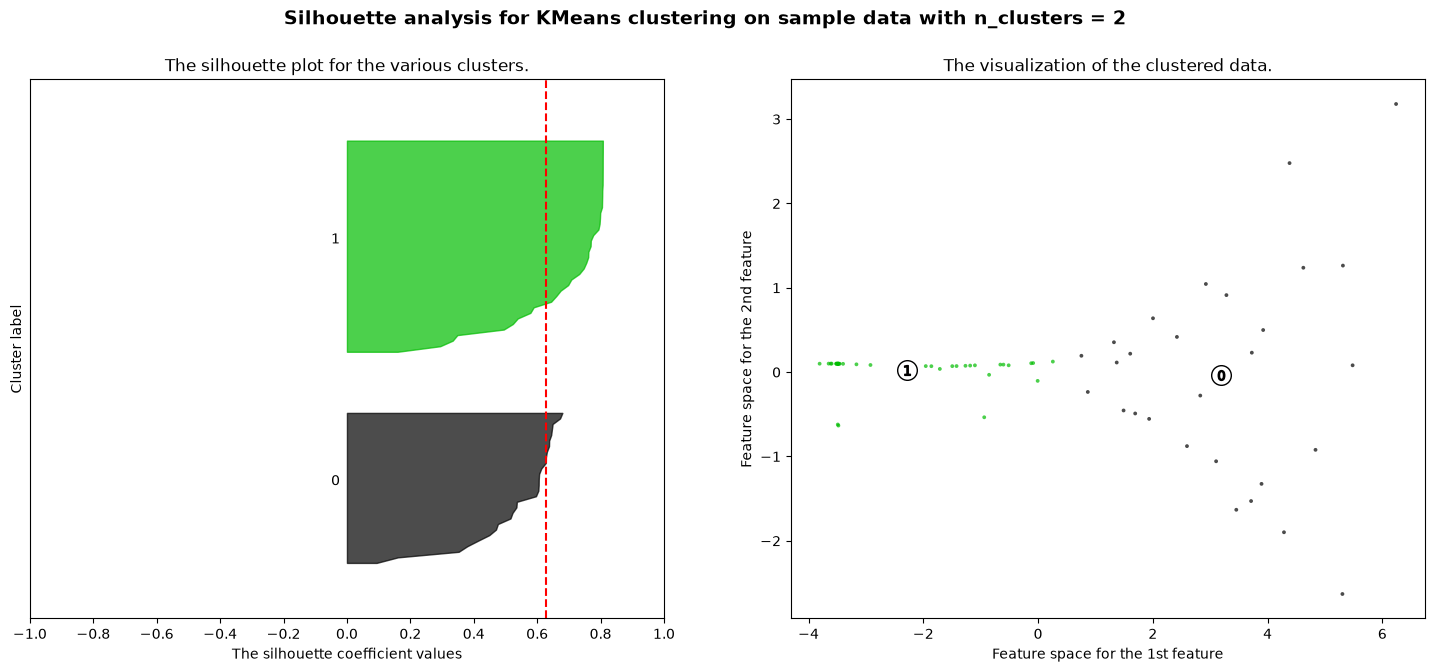

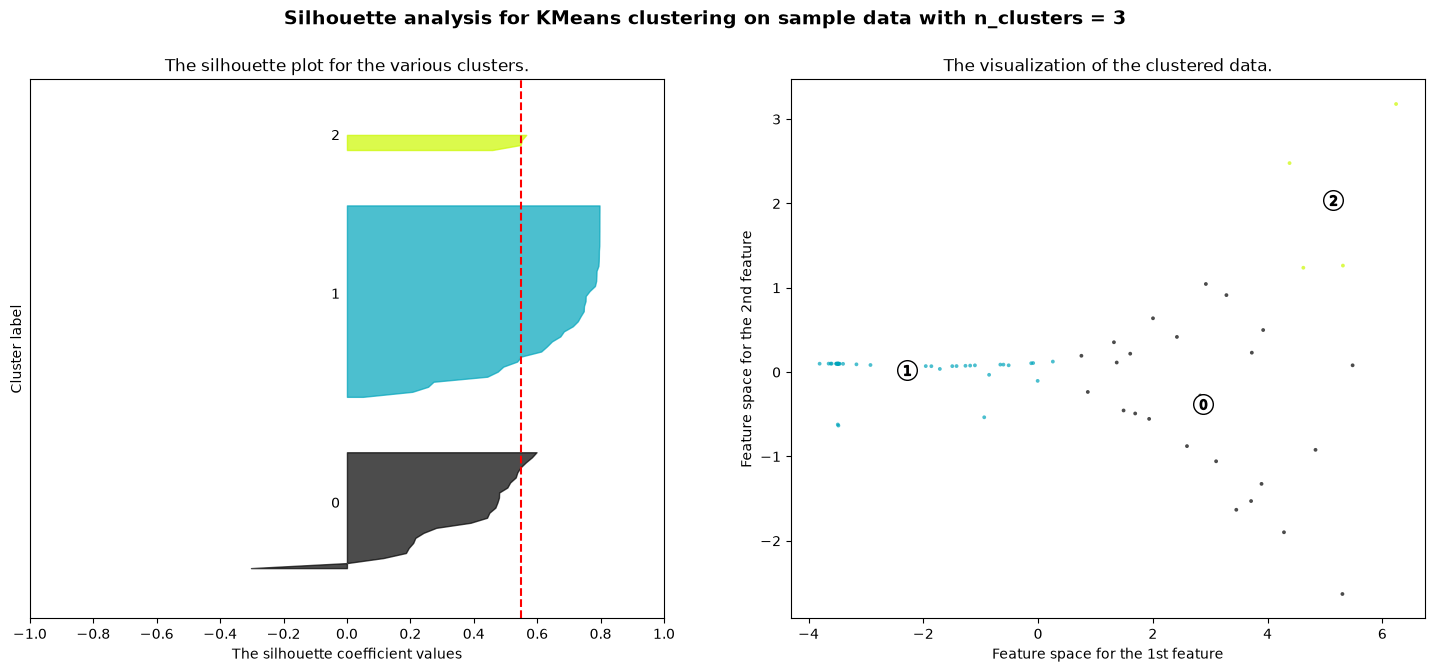

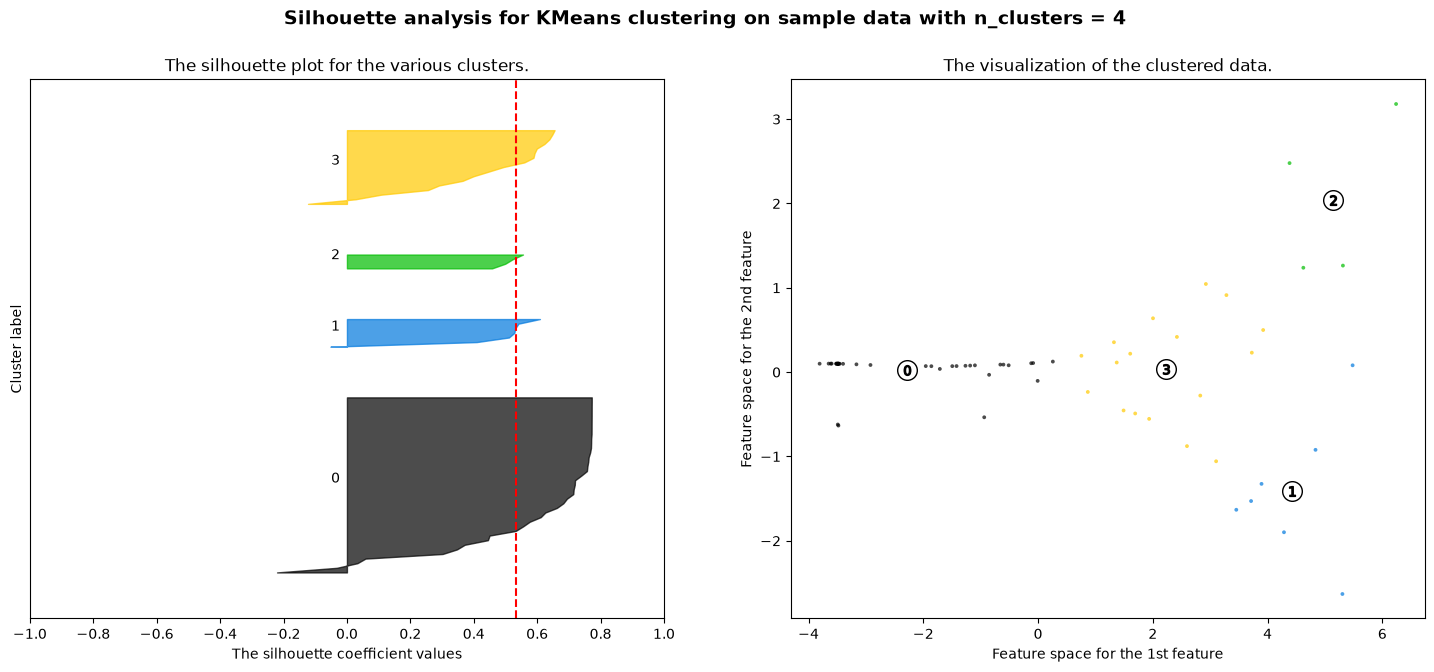

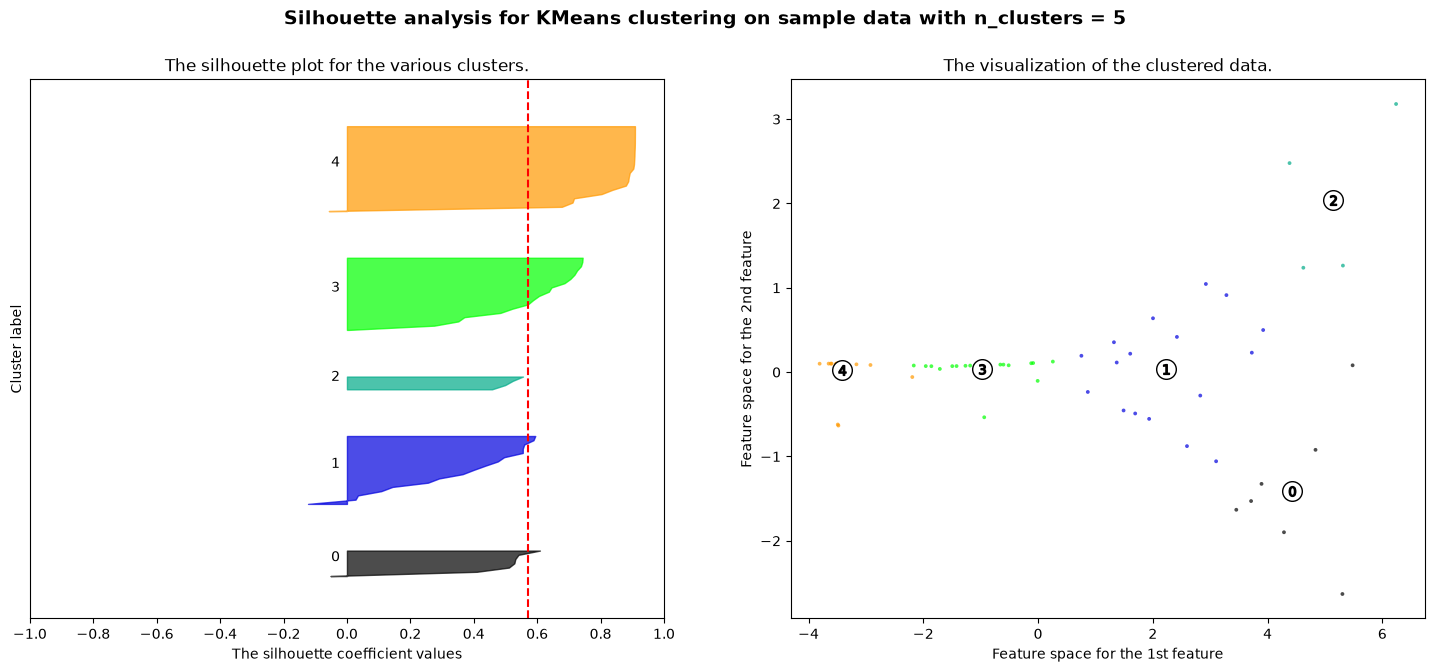

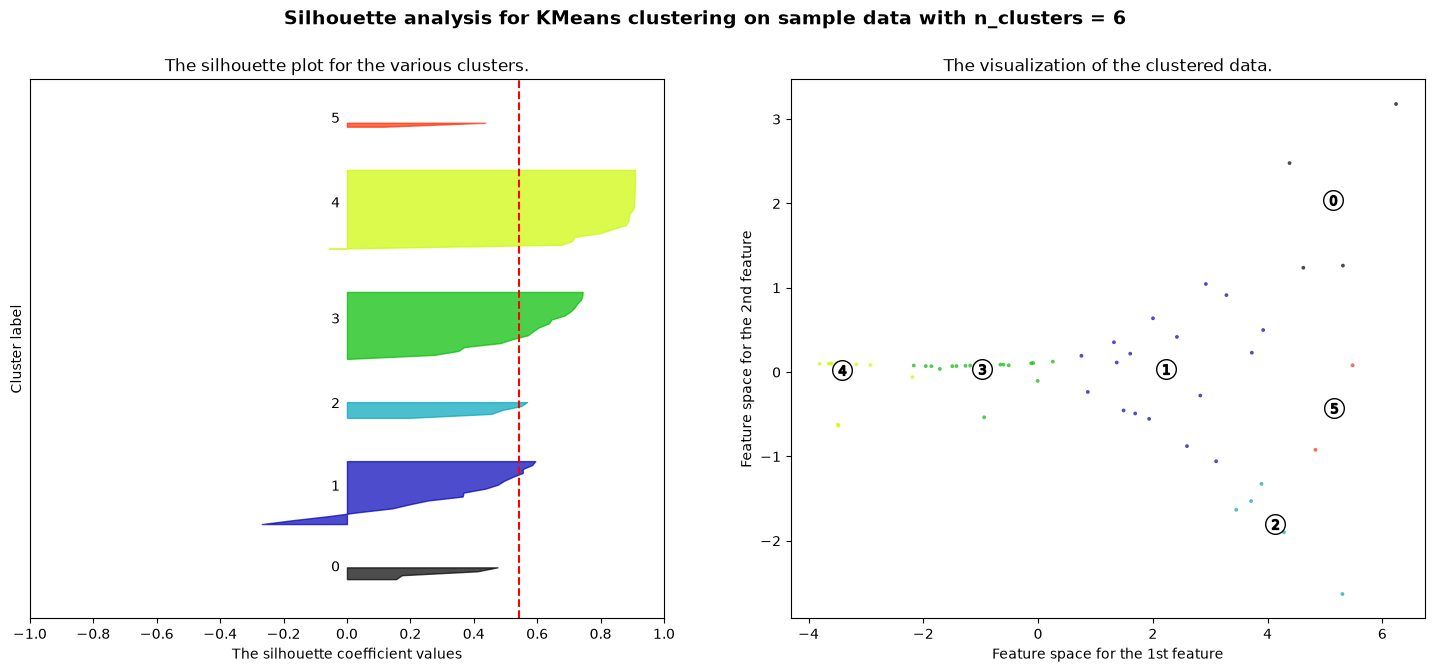

In [74]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score


range_n_clusters = [2, 3, 4, 5, 6]

mds = MDS(n_components=2, metric='precomputed', random_state=42, n_init=1, init='classical_mds')
X = mds.fit_transform(dist_matrix)

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)


    ax1.set_xlim([-1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    clustering = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='precomputed',
        linkage='complete',
    )
    cluster_labels = clustering.fit_predict(dist_matrix)

    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])
    ax1.set_xticks(np.arange(-1, 1.2, 0.2))

    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # # Labeling the clusters
    centers = centers = np.array([X[cluster_labels== i].mean(axis=0) for i in np.unique(cluster_labels)])
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

# Processing patient data

### Loading

In [ ]:
raw_data = pd.read_excel(PATH_PATIENT_DATA)

vars_clust = (
    'Patient',
    #'Sexe',
    'Tabagisme avant le diagnostic (oui/jamais)',
    'Age au diagnostic',                                          #num
    'Type histologique',
    'Stade clinique',
    'PDL1',                                                       #num
    'Molecule n°1',
    'Molecule n°2',
    'Molecule n°3',
    'Nombre de cycle de chimio-immunothérapie',                   #num
)

data_c = raw_data.loc[:, vars_clust]

In [ ]:
n_clusters = 1
dist_matrix = dist_matrix
clustering = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='precomputed',
    linkage='average',
)
labels = clustering.fit_predict(dist_matrix)
clusters = get_slides_cluster(labels, slides_annot, get_tumor_slides(slides_annot))
clusters['cluster'].unique()

### Data cleaning

In [ ]:
def clean_data_clust(df):
    clean_df = df.copy()
    dropped_samples = 0

    clean_df['Patient'] = clean_df['Patient'].str.strip()
    patient_indices = clean_df['Patient'].dropna().index
    clean_df = clean_df.iloc[patient_indices, :]

    missing_val_molecules = [
        'Molecule n°2',
        'Molecule n°3'
    ]
    for col in missing_val_molecules:
        empty_val = clean_df[col] == '.'
        clean_df.loc[empty_val, col] = -1 # new label when the molecule is not used.

    missing_val_feats = [
        'Nombre de cycle de chimio-immunothérapie',
        'Stade clinique',
        'Tabagisme avant le diagnostic (oui/jamais)',
        'Age au diagnostic',
        'Molecule n°1',
        'Molecule n°2',
        'Molecule n°3',
    ]

    for col in missing_val_feats:
        missing_val = pd.to_numeric(
            clean_df[col], errors='coerce'
        ).isna()
        print(f"Cleaning... {col}")
        print(f"Drop samples = {np.sum(missing_val)}  {clean_df['Patient'].values[missing_val]}")
        clean_df.drop(clean_df.index[missing_val], inplace=True)
        dropped_samples += np.sum(missing_val)

    clean_df.reset_index(inplace=True, drop=True)

    vars_num = [
        'Age au diagnostic',
        'PDL1', 
        'Nombre de cycle de chimio-immunothérapie', 
    ]
    vars_cat = [v for v in clean_df.columns if v not in vars_num]

    clean_df[vars_cat] = clean_df[vars_cat].astype('object') #or category ?

    print(f"\nTotal dropped samples = {dropped_samples}")

    return clean_df

def clean_data_desc(clean_df):
    pass

In [ ]:
new_data_c = clean_data_clust(data_c)
new_data_c = new_data_c.merge(clusters, how='inner', left_on='Patient', right_on='id-patient')
new_data_c.drop(labels=['Patient', 'id-patient'], axis=1, inplace=True)

X_raw = new_data_c.loc[:, new_data_c.columns[:-1]]
y = new_data_c.loc[:, 'cluster'].to_numpy()
print(f"X_raw shape : {X_raw.shape}")

vars_num = [
        'Age au diagnostic',
        'PDL1', 
        'Nombre de cycle de chimio-immunothérapie', 
]
vars_cat = [v for v in X_raw.columns if v not in vars_num]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), vars_num),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), vars_cat),
])
X = preprocessor.fit_transform(X_raw)
feats_name = preprocessor.get_feature_names_out()
print(f"X shape : {X.shape}")


X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, test_size=0.3, stratify=y)

### Data analysis

In [ ]:
classes, counts = np.unique(y, return_counts=True)
for cls, c in zip(classes, counts):
    print(f"Classe {cls}: {c} samples")

In [ ]:
corr = np.corrcoef(X_train, y_train, rowvar=False)
plt.matshow(corr)
plt.colorbar();

In [ ]:
corr_strength = np.abs(corr[-1, :-1])
indices = np.argsort(corr_strength)[::-1]
k = 5
print(f"Top {k} strongest correlated features")
for i in range(k):
    if np.isnan(corr_strength[indices[i]]):
        continue
    print(f"{i+1}. {feats_name[indices[i]]}, corr = {corr_strength[indices[i]]:.2f}")

In [ ]:
pca = PCA().fit(X)
plt.bar(np.arange(pca.n_components_), np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.arange(pca.n_components_), np.ones(pca.n_components_)*0.95, c='red', label='95%')
plt.legend()

plt.xlabel('PCA components')
plt.ylabel('Explained variance ratio')
plt.title('Explained variance by pca components')

In [ ]:
import textwrap

def plot_feat_distribution(X, y, figsize=None):
    _, n_feats = X.shape

    if figsize:
        plt.figure(figsize=figsize)
    i = 1
    for c in range(2):
        for col in X:
            plt.subplot(2, n_feats, i)
            plt.hist(X[y==c][col])
            plt.xlabel("Values")
            plt.ylabel("Counts")
            title = textwrap.fill(f"{col}(y={c})", width=25)
            plt.title(title)
            i += 1
    """ plt.subplots_adjust(
        left=0.1, bottom=0.1, right=1, 
        top=0.9, wspace=0.4,hspace=0.4
    ) """
    plt.tight_layout()
    plt.suptitle("Distribution des variables", y=1.1)


In [ ]:
plot_feat_distribution(X_raw, y, figsize=(30,5))

__Analyse__:  
Il y a des variables dont la distribution reste la même quelque soit la classe :  
- Sexe, Tabagisme, PDL1, Type de TTT neoadjuvant, Molecule n°1, nb cycle de maintenance

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), vars_num),
        ("cat", OneHotEncoder(
            min_frequency=0.05,
            handle_unknown="ignore",
        ), vars_cat),
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("select", SelectKBest(score_func=f_classif)),
    ("clf", LogisticRegression(
        l1_ratio=1, solver="liblinear",
        class_weight="balanced", max_iter=1000
    )),
])

param_grid = {
    "select__k": [2, 3, 4, 5, 6, 8],
    "clf__C": [0.01, 0.1, 1, 10],
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline, param_grid,
    scoring="f1_macro", cv=inner_cv, n_jobs=-1
)

outer_cv = LeaveOneOut()

y_pred_nested = cross_val_predict(grid, X_raw, y, cv=outer_cv, n_jobs=-1)

print("=== Rapport de classification (nested CV, honnête) ===")
print(classification_report(y, y_pred_nested))


simple_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("select", SelectKBest(score_func=f_classif, k=5)),
    ("clf", LogisticRegression(
        l1_ratio=1, solver="liblinear",
        C=10, class_weight="balanced", max_iter=1000
    )),
])

score, perm_scores, pvalue = permutation_test_score(
    simple_pipeline, X_raw, y,
    cv=outer_cv,
    scoring="f1_macro", n_permutations=1000, n_jobs=-1, random_state=42
)

print(f"\n=== Test de permutation ===")
print(f"F1-macro observé          : {score:.3f}")
print(f"F1-macro moyen (hasard)   : {perm_scores.mean():.3f}")
print(f"p-value                  : {pvalue:.4f}")


selected_counter = Counter()

for train_idx, _ in outer_cv.split(X_raw, y):
    X_train, y_train = X_raw.iloc[train_idx], y[train_idx]
    grid.fit(X_train, y_train)
    mask = grid.best_estimator_.named_steps["select"].get_support()
    encoded_feature_names = grid.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
    for var in encoded_feature_names[mask]:
        selected_counter[var] += 1

print("\n=== Fréquence de sélection par variable (sur 56 folds) ===")
for var, count in selected_counter.most_common():
    print(f"  {var}: {count}/56 ({100*count/56:.0f}%)")


## Clustering - Optimal Transport

In [ ]:
grid = np.linspace(0, 2, 100)
X = np.array([
    dist['kde']['center'](grid) 
    for _, dist in distribution_data_local.items()
])

for row in X:
    row /= row.sum()

X = X.T

In [ ]:
d, N = X.shape
K = 6                  # Nombre de clusters
max_iter = 50
reg = 2e-3             # Paramètre de régularisation
M = ot.dist(grid.reshape((d, 1)), grid.reshape((d, 1)))
M /= np.max(M)
method = 'sinkhorn_log'

print("Début du clustering...")

init_indices = np.random.choice(N, K, replace=False)
centers = X[:, init_indices].copy()
labels = np.zeros(N)

for iteration in range(max_iter):
    distances = np.zeros((N, K))
    for i in range(N):
        for k in range(K):
            distances[i, k] = ot.sinkhorn2(
                X[:, i], centers[:, k], M, reg, 
                method=method,
            )
            
    new_labels = np.argmin(distances, axis=1)
    
    if np.array_equal(labels, new_labels):
        print(f"Convergence atteinte à l'itération {iteration}.")
        break
    labels = new_labels

    for k in range(K):
        cluster_data = X[:, labels == k]
        if cluster_data.shape[1] > 0:
            centers[:, k] = ot.bregman.barycenter(
                cluster_data, M, reg,
                method=method
            )

labels_ot_kmeans = labels

plt.figure(figsize=(10, 8))
cols = math.ceil(math.sqrt(K))
rows = math.ceil(K / cols)
for k in range(K):
    plt.subplot(rows, cols, k+1)
    cluster_data = X[:, labels == k]
    
    for i in range(cluster_data.shape[1]):
        plt.plot(grid, cluster_data[:, i], color='gray', alpha=0.3)
        
    plt.plot(grid, centers[:, k], color='red', linewidth=3, label='Barycentre Wasserstein')
    
    plt.title(f'Cluster {k+1} (member={cluster_data.shape[1]})')
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
plt.matshow(distances.T)
plt.colorbar()